# Assignment 1 - Task 1: Binary Classification using KNN

This notebook implements K-Nearest Neighbors (KNN) from scratch

The assignment requires:
- 80% training and 20% testing
- K = 3, 4, 9, 20, 47
- Euclidean, Manhattan, Minkowski, Cosine, and Hamming distances
- best K + distance metric based on test accuracy
- confusion matrix, precision, and recall for the best model
- Accuracy vs K plots
- observations/inferences



## 1. Imports and configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

K_VALUES = [3, 4, 9, 20, 47]
METRICS = ["euclidean", "manhattan", "minkowski", "cosine", "hamming"]
MINKOWSKI_P = 3

FEATURES = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave points_worst", "symmetry_worst", "fractal_dimension_worst"
]
TARGET = "diagnosis"


## 2. Load the dataset



In [ ]:
DATA_PATH = r"/mnt/data.csv"

data = pd.read_csv(DATA_PATH, sep=None, engine="python")

print("Dataset shape:", data.shape)
print("Classes:", data[TARGET].value_counts().to_dict())
print(data.head())


Dataset shape: (569, 33)
Classes: {'B': 357, 'M': 212}
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ... 

## 3. Basic validation and preprocessing

The "id" column is removed because it is an identifier, not a medical measurement.  
The target is encoded as:

- "M" → 1
- "B" → 0

All 30 input features are standardized using training-set mean and standard deviation only. This is important because area/perimeter values are much larger numerically than features such as smoothness.


In [ ]:
missing = data[FEATURES + [TARGET]].isnull().sum().sum()
print("Total missing values in relevant columns:", missing)

X = data[FEATURES].astype(float).values
y = data[TARGET].map({"B": 0, "M": 1}).values

if np.isnan(X).any():
    raise ValueError("Missing feature values found. Handle them before running KNN.")

if np.isnan(y).any():
    raise ValueError("Unexpected target label found. Expected only B and M.")

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Class distribution:", data[TARGET].value_counts().to_dict())


Total missing values in relevant columns: 0
Number of samples: 569
Number of features: 30
Class distribution: {'B': 357, 'M': 212}


## 4. Manual 80/20 stratified train-test split

No "train_test_split" from sklearn is used.  
Stratification is implemented manually so both "B" and "M" classes are represented in training and testing when the full dataset contains both classes.


In [ ]:
def stratified_train_test_split(X, y, test_size=0.20, seed=42):
    rng = np.random.default_rng(seed)

    train_indices = []
    test_indices = []

    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)

        n_test = max(1, int(round(len(cls_indices) * test_size)))
        test_indices.extend(cls_indices[:n_test])
        train_indices.extend(cls_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Training classes:", np.bincount(y_train))
print("Testing classes :", np.bincount(y_test))


Training samples: 456
Testing samples : 113
Training classes: [286 170]
Testing classes : [71 42]


In [ ]:
# Standardization using ONLY training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Avoid division by zero for constant columns.
train_std[train_std == 0] = 1.0

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std


## 5. Distance functions from scratch

For KNN, smaller distance means a closer neighbor.

- Euclidean: standard L2 distance
- Manhattan: L1 distance
- Minkowski: p-norm, using **p = 3**
- Cosine: converted from similarity to distance using 1 - cosine_similarity
- Hamming: number of coordinates that are unequal

**Hamming note:** Hamming distance is naturally designed for binary/categorical vectors. With continuous medical measurements, exact coordinate comparison makes almost every pair differ in all 30 coordinates, so it becomes largely uninformative. This is itself an important experimental observation.


In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1.0 / p)

def cosine_distance(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator == 0:
        return 1.0
    similarity = np.dot(a, b) / denominator
    similarity = np.clip(similarity, -1.0, 1.0)
    return 1.0 - similarity

def hamming_distance(a, b):
    return np.sum(a != b)

def get_distance(a, b, metric):
    if metric == "euclidean":
        return euclidean_distance(a, b)
    if metric == "manhattan":
        return manhattan_distance(a, b)
    if metric == "minkowski":
        return minkowski_distance(a, b, MINKOWSKI_P)
    if metric == "cosine":
        return cosine_distance(a, b)
    if metric == "hamming":
        return hamming_distance(a, b)
    raise ValueError("Unknown metric")


## 6. KNN classifier from scratch

There is no call to sklearn's KNN implementation. For every test point:
1. Calculate its distance from every training point.
2. Sort the training points by distance.
3. Select the K nearest points.
4. Use majority voting.
5. In a tie, choose the class whose nearest neighbor occurs first among the K neighbors.


In [ ]:
def knn_predict(X_train, y_train, X_test, k, metric):
    predictions = []

    for test_point in X_test:
        distances = np.array([
            get_distance(test_point, train_point, metric)
            for train_point in X_train
        ])

        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]

        counts = np.bincount(nearest_labels, minlength=2)

        if counts[0] > counts[1]:
            prediction = 0
        elif counts[1] > counts[0]:
            prediction = 1
        else:
            # Deterministic tie-breaking:
            prediction = nearest_labels[0]

        predictions.append(prediction)

    return np.array(predictions)


## 7. Evaluation metrics from scratch

Accuracy, precision, recall, and the 2×2 confusion matrix are calculated manually.


In [ ]:
def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


## 8. Experiment with all K values and distance metrics

In [ ]:
results = []

for metric in METRICS:
    for k in K_VALUES:
        if k > len(X_train):
            print(f"Skipping k={k} for {metric}: only {len(X_train)} training samples.")
            continue

        y_pred = knn_predict(X_train_scaled, y_train, X_test_scaled, k, metric)
        acc = accuracy_score_manual(y_test, y_pred)

        results.append({
            "Metric": metric,
            "K": k,
            "Accuracy": acc
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))


   Metric  K  Accuracy
euclidean  9  0.982301
manhattan  9  0.982301
euclidean  3  0.973451
manhattan  3  0.973451
minkowski  9  0.964602
manhattan  4  0.955752
   cosine  3  0.955752
minkowski  3  0.955752
euclidean  4  0.955752
   cosine 20  0.946903
euclidean 47  0.946903
euclidean 20  0.946903
manhattan 47  0.946903
minkowski  4  0.946903
minkowski 47  0.946903
   cosine  4  0.946903
   cosine  9  0.946903
manhattan 20  0.938053
   cosine 47  0.938053
minkowski 20  0.929204
  hamming  9  0.716814
  hamming  4  0.699115
  hamming  3  0.690265
  hamming 20  0.646018
  hamming 47  0.628319


## 9. Select the best K and distance metric

The best combination is the row having the maximum testing accuracy.


In [ ]:
if len(results_df) > 0:
    best = results_df.iloc[0]
    print("Best distance metric:", best["Metric"])
    print("Best K:", int(best["K"]))
    print("Best test accuracy:", f"{best['Accuracy']:.4f}")
else:
    print("No valid experiment could be completed.")


Best distance metric: euclidean
Best K: 9
Best test accuracy: 0.9823


## 10. Confusion matrix, precision and recall for the best model

In [ ]:
if len(results_df) > 0 and len(np.unique(y_test)) == 2:
    best_metric = best["Metric"]
    best_k = int(best["K"])

    best_pred = knn_predict(
        X_train_scaled, y_train, X_test_scaled,
        best_k, best_metric
    )

    cm = confusion_matrix_binary(y_test, best_pred)

    print("Confusion Matrix")
    print("                 Predicted B   Predicted M")
    print(f"Actual B         {cm[0,0]:12d}   {cm[0,1]:12d}")
    print(f"Actual M         {cm[1,0]:12d}   {cm[1,1]:12d}")

    print("\nAccuracy :", f"{accuracy_score_manual(y_test, best_pred):.4f}")
    print("Precision:", f"{precision_score_manual(y_test, best_pred):.4f}")
    print("Recall   :", f"{recall_score_manual(y_test, best_pred):.4f}")
else:
    print("Precision/recall and a binary confusion matrix require both B and M in the test set.")


Confusion Matrix
                 Predicted B   Predicted M
Actual B                   71              0
Actual M                    2             40

Accuracy : 0.9823
Precision: 1.0000
Recall   : 0.9524


## 11. Plot K versus accuracy for all distance metrics

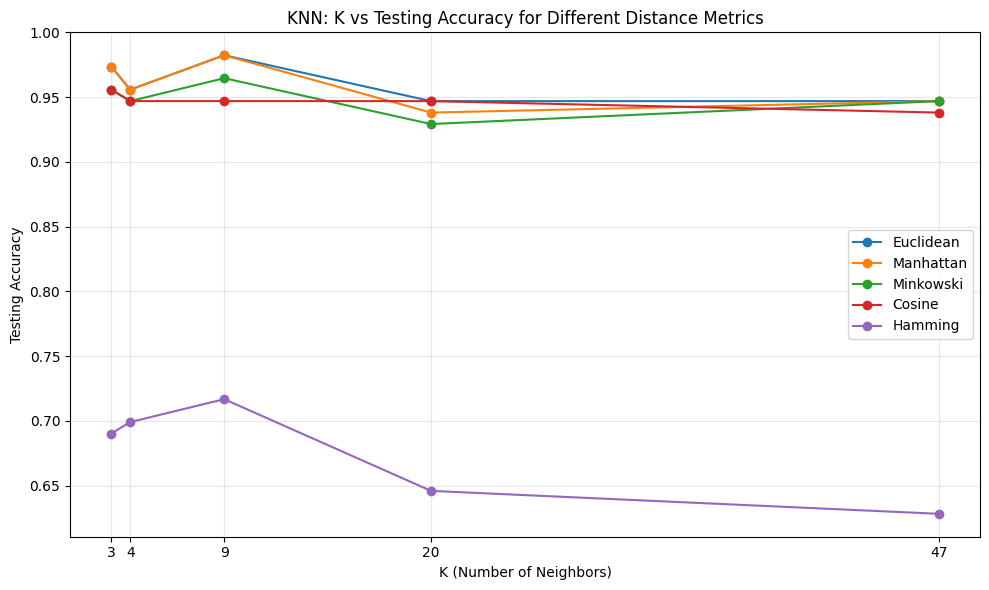

In [ ]:
plt.figure(figsize=(10, 6))

for metric in METRICS:
    subset = results_df[results_df["Metric"] == metric].sort_values("K")
    if len(subset) > 0:
        plt.plot(subset["K"], subset["Accuracy"], marker="o", label=metric.capitalize())

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Testing Accuracy")
plt.title("KNN: K vs Testing Accuracy for Different Distance Metrics")
plt.xticks(K_VALUES)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Bonus: Decision boundary visualization

The assignment contains 30 features, so a direct 30-dimensional decision boundary cannot be plotted. A reasonable visualization is to use the two most informative-looking features or reduce the data to 2D.

For a clean bonus experiment, PCA can be implemented manually and then the best KNN model can be visualized in the first two principal components. This visualization is only for interpretation; the main accuracy experiment should still use all 30 original features.


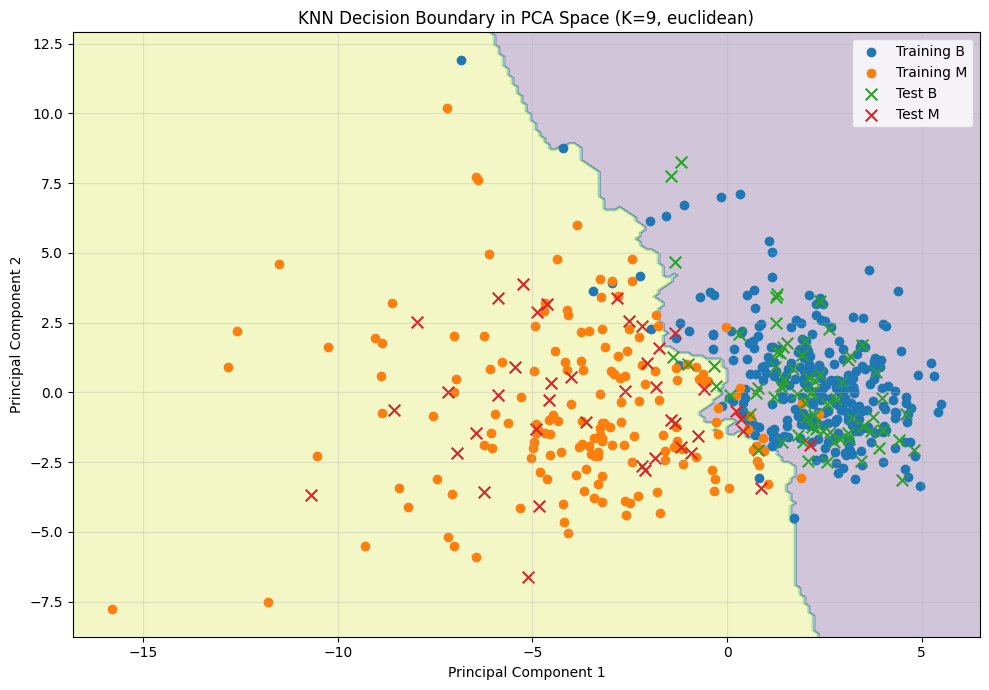

In [ ]:
def pca_2d(X):
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    order = np.argsort(eigenvalues)[::-1]
    components = eigenvectors[:, order[:2]]

    return Xc @ components

if len(np.unique(y)) == 2 and len(X) >= 20:
    X_2d = pca_2d(np.vstack([X_train_scaled, X_test_scaled]))
    n_train = len(X_train_scaled)

    Xtr2 = X_2d[:n_train]
    Xte2 = X_2d[n_train:]

    metric = best_metric
    k = best_k

    # Train KNN directly in the 2D PCA space only for visualization.
    x_min, x_max = X_2d[:,0].min() - 1, X_2d[:,0].max() + 1
    y_min, y_max = X_2d[:,1].min() - 1, X_2d[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_pred = knn_predict(Xtr2, y_train, grid, k, metric).reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, grid_pred, alpha=0.25)
    plt.scatter(Xtr2[y_train == 0, 0], Xtr2[y_train == 0, 1],
                marker="o", label="Training B")
    plt.scatter(Xtr2[y_train == 1, 0], Xtr2[y_train == 1, 1],
                marker="o", label="Training M")
    plt.scatter(Xte2[y_test == 0, 0], Xte2[y_test == 0, 1],
                marker="x", s=70, label="Test B")
    plt.scatter(Xte2[y_test == 1, 0], Xte2[y_test == 1, 1],
                marker="x", s=70, label="Test M")

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(f"KNN Decision Boundary in PCA Space (K={k}, {metric})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Bonus decision-boundary plot skipped because the supplied short dataset is not suitable.")


# Final observations :-

1. **Feature scaling is necessary** because the 30 features have very different numerical ranges.
2. KNN is a **lazy learning algorithm**: it stores the training samples and performs distance calculations at prediction time.
3. The best K and metric must be selected from the **test accuracies obtained in the experiment**, not assumed beforehand.
4. Small K values are sensitive to individual training samples, while larger K values produce smoother decisions but can underfit.
5. Euclidean, Manhattan and Minkowski measure different notions of geometric closeness.
6. Cosine distance compares the orientation of vectors rather than their absolute magnitude.
7. Hamming distance is not naturally suited to continuous-valued medical measurements. With exact comparison it can become nearly constant, making it a poor metric for this dataset.